In [3]:
import numpy as np
import matplotlib.pyplot as plt


def rope_theta(k, i, d, base=10000):
    """
    θ(k, i) = k * base^(-2i/d)
    """
    omega = base ** (-2 * np.asarray(i) / d)
    return np.asarray(k)[..., None] * omega


def plot_rope_theta(
    d=128,
    base=10000,
    max_k=4096,
    num_k=None,
    wrap=True
):
    """
    Visualize RoPE rotation angle θ(k, i).

    x-axis: token position k
    y-axis: pair index i
    color: rotation angle θ
    """

    num_pairs = d // 2

    if num_k is None:
        num_k = max_k

    # Token positions
    k = np.linspace(0, max_k - 1, num_k)

    # Pair indices
    i = np.arange(num_pairs)

    # Frequency for each pair
    omega = base ** (-2 * i / d)

    # Rotation angle
    theta = k[:, None] * omega[None, :]

    if wrap:
        theta_plot = theta % (2 * np.pi)
        color_label = r"$\theta\ \mathrm{mod}\ 2\pi$"
    else:
        theta_plot = theta
        color_label = r"$\theta(k,i)$"

    fig, ax = plt.subplots(figsize=(14, 7))

    im = ax.imshow(
        theta_plot.T,
        aspect="auto",
        origin="lower",
        extent=[
            0,
            max_k - 1,
            0,
            num_pairs - 1
        ],
        cmap="twilight"
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(color_label)

    ax.set_xlabel("Token position $k$")
    ax.set_ylabel("Pair index $i$")

    ax.set_title(
        f"RoPE Rotation Angle — d={d}, base={base:,}"
    )

    plt.tight_layout()
    plt.show()

    return k, i, omega, theta

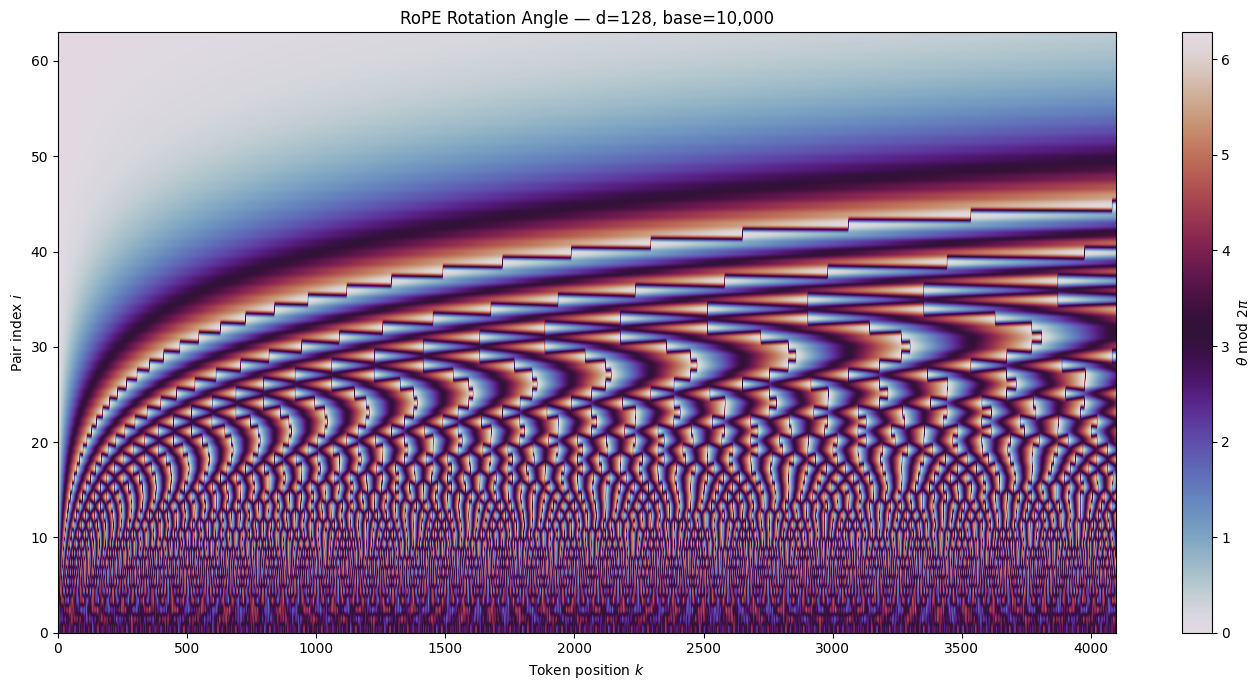

In [ ]:
k, i, omega, theta = plot_rope_theta(
    d=128,
    base=10000,
    max_k=4096
)

# Damn, look at how rapidly the rotation angles change at low pair indices zone (0-5), while as we move up in y-axis, the change in rotation angle becomes more moderate
# For a fixed pair of index (dim1, dim2), the rotation angle changes linearly with token_position (NOTE: we are using rotation_angle mod 2pi here (not just rotation_angle) on righty-axis)
# For a fixed token position (k), rotation angle increases non-linearly with pair index.